In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

In [3]:
data_train_path = 'Fruits_Vegetables/train'
data_test_path = 'Fruits_Vegetables/test'
data_val_path = 'Fruits_Vegetables/validation'

In [4]:
img_width = 180
img_height = 180

In [5]:
data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle = True,
    image_size = (img_width , img_height),
    batch_size = 32,
    validation_split = False)

Found 3115 files belonging to 36 classes.


In [48]:
data_cat = data_train.class_names

In [49]:
data_cat

['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']

In [7]:
data_val = tf.keras.utils.image_dataset_from_directory(
    data_val_path,
    shuffle = False,
    image_size = (img_width , img_height),
    batch_size = 32,
    validation_split = False)

Found 351 files belonging to 36 classes.


In [8]:
data_test = tf.keras.utils.image_dataset_from_directory(
    data_test_path,
    shuffle = False,
    image_size = (img_width , img_height),
    batch_size = 32,
    validation_split = False)

Found 359 files belonging to 36 classes.


In [9]:
from tensorflow.keras.models import Sequential

In [10]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [17]:
model = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(len(data_cat))
])

In [18]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [20]:
epochs_size = 25
history = model.fit(data_train, validation_data=data_val, epochs= epochs_size)

Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 78s 787ms/step - accuracy: 0.1608 - loss: 3.0782 - val_accuracy: 0.4160 - val_loss: 2.1080
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 71s 711ms/step - accuracy: 0.3746 - loss: 2.1789 - val_accuracy: 0.6410 - val_loss: 1.1922
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 71s 709ms/step - accuracy: 0.5403 - loss: 1.6012 - val_accuracy: 0.8034 - val_loss: 0.7393
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 73s 726ms/step - accuracy: 0.6973 - loss: 1.0494 - val_accuracy: 0.8746 - val_loss: 0.5115
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 73s 728ms/step - accuracy: 0.8128 - loss: 0.6386 - val_accuracy: 0.9060 - val_loss: 0.3878
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 73s 725ms/step - accuracy: 0.8931 - loss: 0.3866 - val_accuracy: 0.9373 - val_loss: 0.3695
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 70s 703ms/step - accuracy: 0.9310 - loss: 0.2793 - val_accuracy: 0.9430 - val_loss: 0.3125
Epoch 8/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 74s 748ms/step - accuracy: 0.9445 - loss: 0.2164 - val_accu

Text(0.5, 1.0, 'Loss')

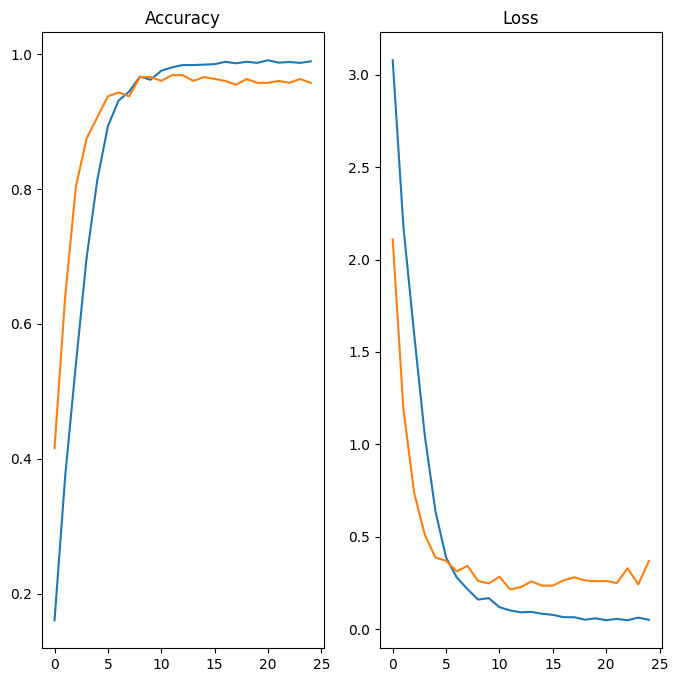

In [21]:
epochs_range = range(epochs_size)
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(epochs_range,history.history['accuracy'],label = 'Training Accuracy')
plt.plot(epochs_range,history.history['val_accuracy'],label = 'Validation Accuracy')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,history.history['loss'],label = 'Training Loss')
plt.plot(epochs_range,history.history['val_loss'],label = 'Validation Loss')
plt.title('Loss')

In [43]:
image = 'ca1.jpg'
image = tf.keras.utils.load_img(image, target_size=(img_height, img_width))
img_arr = tf.keras.utils.array_to_img(image)
img_bat = tf.expand_dims(img_arr,0)

In [44]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


In [45]:
score = tf.nn.softmax(predict)

In [46]:
print('Veg/Fruit in image is {} with accuracy of {:0.2f}'.format(data_cat[np.argmax(score)],np.max(score)*100))

Veg/Fruit in image is bell pepper with accuracy of 44.48


In [47]:
model.save('Image_clasify.keras')